<div style="background: linear-gradient(135deg, rgb(196, 196, 196) 0%, #5a5a5aeb 50%, rgb(0, 0, 0) 100%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Data Preparation**
</div>

Ноутбук по очистке данных.

Цель - выполнить предобработку и очистку данных, (в нашем случае твитов) для последующего анализа и подготовки к обучению моделей.

Основные задачи:
1. Выполнить загрузку данных (на вход подаются сырые данные из твитов файла tweets.txt) и провести первичный анализ;
2. Выполнить подготовительную очистку данных;
3. Проверка на аномальность в данных.

In [2]:
# Импорт основных библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import emoji

import re
import html

In [3]:
# Читаем файл целиком и разбиваем по строкам
with open('data/tweets.txt', 'r', encoding='utf-8') as file:
    tweets = file.read().splitlines()

# Создаем DataFrame
data = pd.DataFrame(tweets, columns=['text'])

Предварительно, чтобы случайно не нарушить структуру и заполнение начальных данных создадим копию датасета, и будем работать в ней

In [4]:
df = data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601127 entries, 0 to 1601126
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   text    1601127 non-null  object
dtypes: object(1)
memory usage: 12.2+ MB


In [5]:
df

,text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,is upset that he can't update his Facebook by ...
2,@Kenichan I dived many times for the ball. Man...
3,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all...."
...,...
1601122,Ask Programming: LaTeX or InDesign?: submitted...
1601123,"On that note, I hate Word. I hate Pages. I hat..."
1601124,Ahhh... back in a *real* text editing environm...
1601125,"Trouble in Iran, I see. Hmm. Iran. Iran so far..."


В первичном анализе мы видим, что в тексте у нас есть упоминания кто делал твит, есть ссылки, шрифт в разном регистре, эмодзи, хэштеги всё это дело нужно подчистить и подготовить для работы модели.



> Сразу оговорка о том, что изначально при первичной работе модели использовался очищенный датасет со множество знаков `!!!!! ....` и так далее. Они были оставленны, по той причине, что твиты являются эмоциональным повествованием по своей природе, и они могут интерпретироваться как часть языка соцсетей, для целей лучшего понимания модели стиля повествования в твитах. Но к сожалению, в данном случае это не помогло, и модель часто использовала множество `....` при генерации. Поэтому было принято решение избавиться от множества знаков препинания.

In [6]:
def clean_tweet(text, remove_hashtags=True):
    """Функция предварительной обработки текста

    Args:
        text (_type_): колонка с текстом
        remove_hashtags (bool, optional): работа с хэштегами True - удаляет хэштег вместе со словом
                                                             False - удаляет просто символ #
    """
    import re
    import emoji

    if not isinstance(text, str):
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем ссылки (http://, https://, www.)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Удаляем упоминания (@username)
    text = re.sub(r'@\w+', '', text)

    # Удаляем после ссылок и упоминаний тире "- "
    text = re.sub(r'^- "', '', text)

    if remove_hashtags:
        text = re.sub(r'#\w+', '', text)
    else:
        text = re.sub(r'#(\w+)', r'\1', text)

    # Удаляем смайлы
    text = emoji.replace_emoji(text, replace='')

    # Обработка множественных знаков препинания
    text = re.sub(r'\.{3,}', '.', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)
    text = re.sub(r',{2,}', ',', text)
    text = re.sub(r'[!?]+[?!]+', '?', text)
    text = re.sub(r'(\w+\.)(?=\s|$)', r'\1 ', text)

    # Удаляем лишние пробелы после обработки знаков препинания
    text = re.sub(r'\s+', ' ', text)

    # Удаляем пробелы перед знаками препинания
    text = re.sub(r'\s+([.,!?])', r'\1', text)

    # Удаляем пробелы в начале и конце
    text = text.strip()

    return text

In [7]:
print(f'Количество строк до чистки: {df.shape[0]}')

Количество строк до чистки: 1601127


In [8]:
print(f'Количество до чистки: {df.shape[0]} строк')

# Применяем очистку
df['clean_text'] = df['text'].apply(clean_tweet)

# Удаляем пустые строки после очистки
df = df[df['clean_text'] != ''].reset_index(drop=True)

print(f'Количество после чистки: {df.shape[0]} строк')

Количество до чистки: 1601127 строк
Количество после чистки: 1598071 строк


Когда мы подвели под единый вид, проверим твиты на дубликаты. Ведь некоторые пользователи могут просто копировать комментарии друг друга, не так ли?

In [9]:
duplicates_count = df.duplicated(subset=['clean_text']).sum()
print(f"Количество дубликатов: {duplicates_count} строк")

df = df.drop_duplicates(subset=['clean_text'], keep='first').reset_index(drop=True)
print(f'Количество после удаления дубликатов: {df.shape[0]} строк')

Количество дубликатов: 60267 строк
Количество после удаления дубликатов: 1537804 строк


Отлично, дубликаты у нас убраны, теперь встает вопрос с длиной комментариев, понятно дело, форма для заполнения твитов может быть стандартизованна по количеству твитов, но рассмотрим две ситуации:
1. Твит состоящий из менее 5 символов. Зачем он нам и какую информацию может нести?
1. Твиты которые являются огромным массивом текста, возможно кто-то вместо ссылки взял скопировал пачку текста и вкинул.

Проверим это дело с нашими данными:

In [10]:
# Создаем колонку с длиной текста
df['text_length'] = df['clean_text'].astype(str).str.len()

In [11]:
print("Статистика по длине комментариев:")
print(df['text_length'].describe())

Статистика по длине комментариев:
count    1.537804e+06
mean     6.639187e+01
std      3.478127e+01
min      1.000000e+00
25%      3.700000e+01
50%      6.100000e+01
75%      9.400000e+01
max      3.600000e+02
Name: text_length, dtype: float64


In [12]:
def plot_text(df, column_name='text_length'):
    """Функция для построения гистограммы и boxplot

    Args:
        df (_type_): DataFrame, содержащий данные для визуализации.
        column_name (str, optional): Назнвание колонки.
    """
    plt.figure(figsize=(12, 5))

    # Гистограмма
    plt.subplot(1, 2, 1)
    plt.hist(df[column_name], bins=50, edgecolor='black')
    plt.title('Распределение длины комментариев')
    plt.xlabel('Длина комментария')
    plt.ylabel('Количество комментариев')

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(df[column_name])
    plt.title('Boxplot длины комментариев')
    plt.ylabel('Длина комментария')

    plt.tight_layout()
    plt.show()

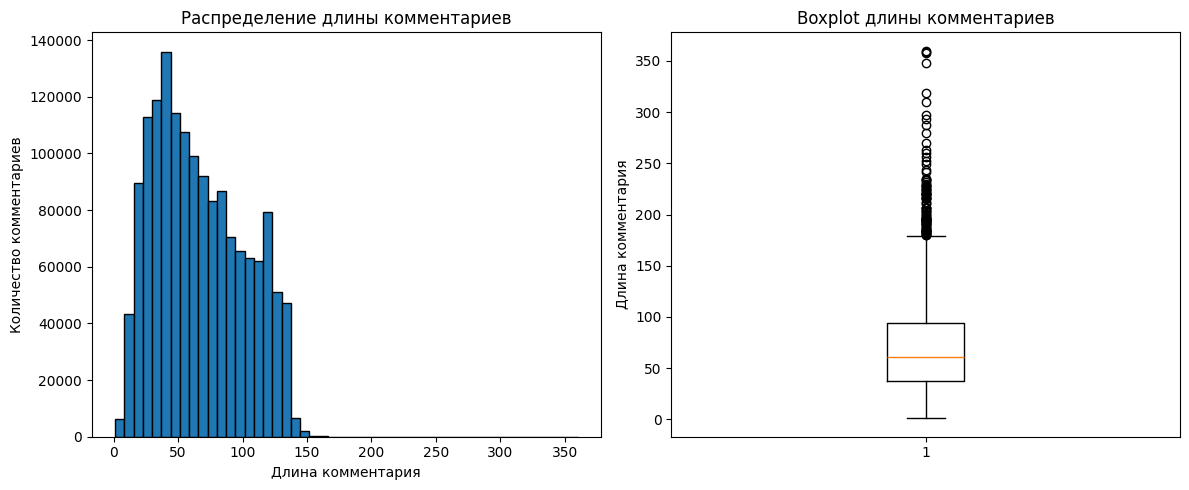

In [13]:
plot_text(df)

Итого, у нас есть комментарии с длинной даже 1 символ, и с длинной символов более 300. Но судя по ящику с усами, их не так много и выглядят они даже как аномалии.
Посмотрим на это дело точечно

In [14]:
df[df.text_length>300]

,text,clean_text,text_length
370133,@neospace à¹à¸£à¸·à¹à¸­à¸à¸à¸±à¹à¸à¸à¸£...,à¹à¸£à¸·à¹à¸­à¸à¸à¸±à¹à¸à¸à¸£à¸£à¸à¹à...,348
1248591,@catfish_ohm à¹à¸à¹à¸²à¹à¸«à¹à¸?à¸²à¸£à¹...,à¹à¸à¹à¸²à¹à¸«à¹à¸?à¸²à¸£à¹à¸à¸¹à¸à¸?à...,360
1308460,@thanr à¹à¸à¸µà¹à¸¢à¸§à¹à¸­à¸²à¸£à¸²à¸à¸²...,à¹à¸à¸µà¹à¸¢à¸§à¹à¸­à¸²à¸£à¸²à¸à¸²à¹à¸à...,310
1396200,@KaewGB à¸­à¹à¸­ à¹à¸à¸¢à¸à¸²à¸¡à¹à¹à¸...,à¸­à¹à¸­ à¹à¸à¸¢à¸à¸²à¸¡à¹à¹à¸à¸à¸µà¹...,319
1428174,@iannnnn à¹à¸à¸µà¹à¸¢à¸§à¸­à¸µà¸?à¸à¸±à¸?à...,à¹à¸à¸µà¹à¸¢à¸§à¸­à¸µà¸?à¸à¸±à¸?à¸à¸£à¸¹à...,359
1521103,5 days till new top gear î?î?î?î?î?î?î?...,5 days till new top gear î?î?î?î?î?î?î?...,358


И тут я немного поднапрягся, а что это такое?

Может я кодировку при чтении выбрал не ту, или ещё чего.. а по факту, когда залез в датасет изначальный и точечно проверил через ctrl+f по @users увидел, что среди 1,6 млн строк прятались подобные твиты.

Возможно плохо скопировали вставили пользователи, возможно проблема с парсингом ну и других вариантов много, по итогу есть твиты с битой кодировкой. Самое главное, что мы это увидели, и надо бы почистить.

Но второй этап чистки будет состоять из:
- Проверка на содержания только английских символов - потому что латиница и другие языке у нас находятся в битой кодировке вот такие ребята - `à¹à¸à¸µà¹à¸¢à¸§à¸­à¸µà¸?à¸à¸`
- у нас обнаружились HTLM сущности - `&gt;, &amp;, &quot` и спецсимволы - `@!)(*&`
- строки где куча цифр и символов - `1937709212130892`

In [15]:
def clean_tweet_second(df, text_column='clean_text'):
    """Функция для глубокой обаботки текста

    Args:
        df (_type_): колонка с текстом
        text_column (str, optional): выбираем колонку по который пойдет чистка, в нашем случае уже
        ранее обработанная колонка.
    """

    def is_english(text):
        # Удаляем не английские символы
        try:
            text.encode('ascii')
            return True
        except:
            return False

    def clean_text(text):
        # html сущности
        text = html.unescape(text)

        # спецсимволы
        text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\-]', ' ', text)

        # длинные числа
        text = re.sub(r'\d{8,}', ' ', text)

        # нормализуем пробелы
        text = ' '.join(text.split())

        # Удаляем слова состоящие из цифр и из одного символа
        words = text.split()
        words = [w for w in words if not (w.isdigit() and len(w) > 4)]
        words = [w for w in words if len(w) > 1 or w.lower() in ['a', 'i']]
        return ' '.join(words)

    df = df[df[text_column].apply(is_english)].copy()
    df[text_column] = df[text_column].apply(clean_text)

    return df

In [16]:
# Почистим
df = clean_tweet_second(df)
df = df.dropna()

In [17]:
print(f"Количество записей после второго этапа чистки: {len(df)}")
print(f"Количество NaN в столбце clean_text: {df['clean_text'].isna().sum()}")

Количество записей после второго этапа чистки: 1523012
Количество NaN в столбце clean_text: 0


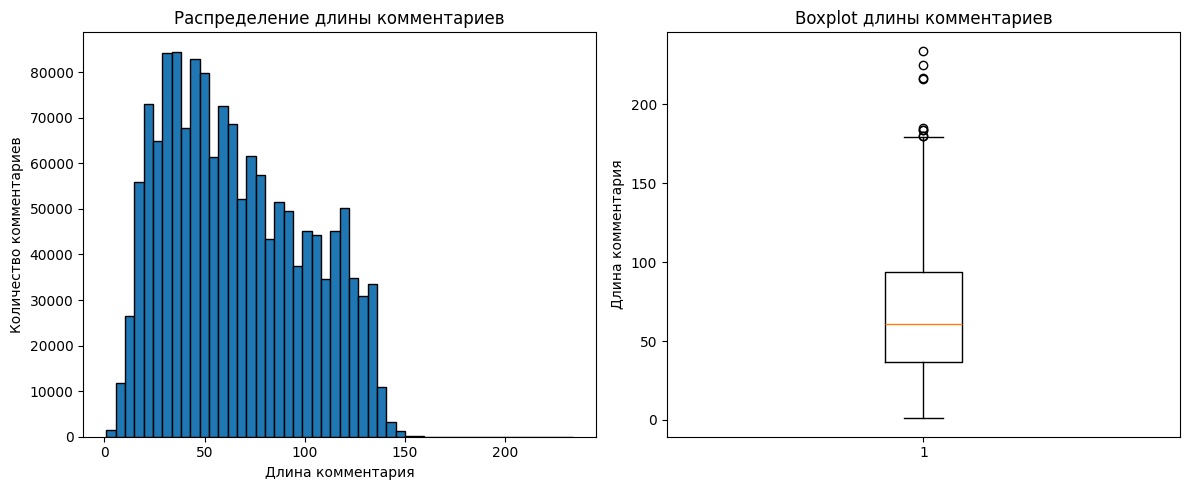

In [18]:
# Проверим как изменилась картина
plot_text(df)

In [19]:
# Посмотрим что выходит из усов
df[df.text_length>170]

,text,clean_text,text_length
28816,"Maybe it's just me, but when someone tells me ...","maybe it's just me, but when someone tells me ...",185
103855,went on yahoo the headline was &quot;michael p...,went on yahoo the headline was michael phelps ...,176
381482,HATE HATE HATE admin - my admin file labels re...,hate hate hate admin my admin file labels read...,172
391692,Raining steady in my neck of the woods &quot;&...,raining steady in my neck of the woods my teen...,180
523025,&quot;i leave you in good hands&quot;. a froze...,i leave you in good hands a frozen tundra with...,177
545217,"Oh no. When I move in a few weeks, I'm going t...","oh no. when i move in a few weeks, i'm going t...",172
576808,Me: &quot;I can't stop getting fat.&quot; Rach...,me i can't stop getting fat. rachel hahaha me ...,174
596083,so 3.0 update changes some of the text &quot;s...,so 3.0 update changes some of the text suggest...,184
656931,I love that he &quot;closed&quot; with &quot;F...,i love that he closed with fake palindromes on...,179
688100,ppl were totally doing &quot;photo shoots&quot...,ppl were totally doing photo shoots with model...,173


In [20]:
# Короткие
df[df.text_length<=5]

,text,clean_text,text_length
191,@HillyDoP oH NO,oh no,5
496,@Anistorm Sorry,sorry,5
610,@thousand_miles no,no,2
704,@polhillian YUP.,yup.,4
931,@mattycus *cry*,cry,5
...,...,...,...
1532355,@manuchis Voy,voy,3
1532634,@tphaley ILY x,ily,5
1534068,@essteeyou Yahup,yahup,5
1534201,add @CalebFTSK,add,3


Длинные фразы можно оставить, они в целом выглядят не плохо, но короткие, где символов менее 5..даже не знаю что модель должна дополнять.
Удалим их, а там в процессе обучения поймем, возвращать это дело или нет.

In [21]:
df = df[df.text_length>=7]

In [22]:
print(f'Количество после чистки: {df.shape[0]} строк')

Количество после чистки: 1520731 строк


На этом этапе подготовку с чисткой считаю законченной, удаляем лишние колонки, и сохраняем датасет

In [23]:
# дропаем колонки лишние
df = df.drop(columns=['text', 'text_length'])

# сохраняем в двух форматах для удобства csv
df.to_csv(
    'data/trcleaned_tweets.csv',
    index=False,
    encoding='utf-8-sig',
    sep='\n'
)

# в txt
with open('data/trcleaned_tweets.txt', 'w', encoding='utf-8-sig') as f:
    for text in df['clean_text']:
        f.write(str(text) + '\n')

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(126, 126, 126) 0%, #f4f4f4 30%, #ffffff 60%, #000000 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Выводы</strong>
</div>

**Итого:**

Начальный датасет состоял из 1 601 127 строк, после чистки вышло 1 520 731. 
Примерно 5% вышла чистка, не плохой результат, что говорит о следующем:
- исходный датасет был довольно чистым
- большинство твитов действительно была на англиском языке
- наша чистка оказалать довольно щадящей

**Выполнена:**
- первичная чистка (Приведение к нижнему регистру, удаления URL, обработка хэштегов и нормализация знаков препинания и удаления эмодзи);
- удаление дубликатов;
- анализ длины текстов;
- выделены основные статистические описания твитов (min, max, meen);
- построенны визаульные распределения;
- выявлены аномальные значения твитов;
- проведена глубокая очистка (языковая фильтрация, декодирование HTML сущностей, удалены спецсимволы и длинные номера и т.д.);
- Убраны пустые строки;
- отфильтровали шум.

Кароче говоря, подготовлен чистый датасет англоязычных твитов, готовый для дальнейшего анализа!